In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import squarify
from scipy.stats import rankdata
import seaborn as sns
import matplotlib.cm as cm

path = kagglehub.dataset_download("sefercanapaydn/mission-launches")

In [2]:
# Obtenemos la base de datos
path = kagglehub.dataset_download("sefercanapaydn/mission-launches")
path = path + r"\mission_launches.csv"
print("Path to dataset files:", path)

Path to dataset files: C:\Users\marco\.cache\kagglehub\datasets\sefercanapaydn\mission-launches\versions\1\mission_launches.csv


In [3]:
df = pd.read_csv(path)

In [4]:
df.to_csv("df.csv")

In [5]:
# Primero vemos qué variables tenemos.

df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [8]:
df["Date"].info

<bound method Series.info of 0       Fri Aug 07, 2020 05:12 UTC
1       Thu Aug 06, 2020 04:01 UTC
2       Tue Aug 04, 2020 23:57 UTC
3       Thu Jul 30, 2020 21:25 UTC
4       Thu Jul 30, 2020 11:50 UTC
                   ...            
4319    Wed Feb 05, 1958 07:33 UTC
4320    Sat Feb 01, 1958 03:48 UTC
4321    Fri Dec 06, 1957 16:44 UTC
4322    Sun Nov 03, 1957 02:30 UTC
4323    Fri Oct 04, 1957 19:28 UTC
Name: Date, Length: 4324, dtype: object>

## Aquí empieza el análisis de datos

In [9]:
# ¿Cuántas misiones se hicieron en total?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [10]:
# ¿Cuántas misiones se hicieron por año?

# Primero revisamos el formato de la columna "Date".
print(df.loc[0:10, "Date"])
# Vemos que el formato es:
# %a %b %d %Y %H:%M %UTC
formato_fecha = "%a %b %d, %Y %H:%M %UTC"

# Convertimos la columna date es formato date diciéndole a Pandas correctamente cómo entender esa información.
df["Date"] = pd.to_datetime(df["Date"], format="mixed", utc=True)
print(df.loc[0:10, "Date"])
# Ahora que ya tenemos la hora convertida correctamente podemos trabajar con el tiempo sin problemas.

0     Fri Aug 07, 2020 05:12 UTC
1     Thu Aug 06, 2020 04:01 UTC
2     Tue Aug 04, 2020 23:57 UTC
3     Thu Jul 30, 2020 21:25 UTC
4     Thu Jul 30, 2020 11:50 UTC
5     Sat Jul 25, 2020 03:13 UTC
6     Thu Jul 23, 2020 14:26 UTC
7     Thu Jul 23, 2020 04:41 UTC
8     Mon Jul 20, 2020 21:30 UTC
9     Sun Jul 19, 2020 21:58 UTC
10    Wed Jul 15, 2020 13:46 UTC
Name: Date, dtype: object
0    2020-08-07 05:12:00+00:00
1    2020-08-06 04:01:00+00:00
2    2020-08-04 23:57:00+00:00
3    2020-07-30 21:25:00+00:00
4    2020-07-30 11:50:00+00:00
5    2020-07-25 03:13:00+00:00
6    2020-07-23 14:26:00+00:00
7    2020-07-23 04:41:00+00:00
8    2020-07-20 21:30:00+00:00
9    2020-07-19 21:58:00+00:00
10   2020-07-15 13:46:00+00:00
Name: Date, dtype: datetime64[ns, UTC]


In [11]:
# Ahora agrupamos por año para responder la pregunta que nos interesa.
misiones_por_año = df.groupby(df['Date'].dt.year).size()
misiones_por_año

Date
1957      3
1958     28
1959     20
1960     39
1961     52
       ... 
2016     90
2017     92
2018    117
2019    109
2020     63
Length: 64, dtype: int64

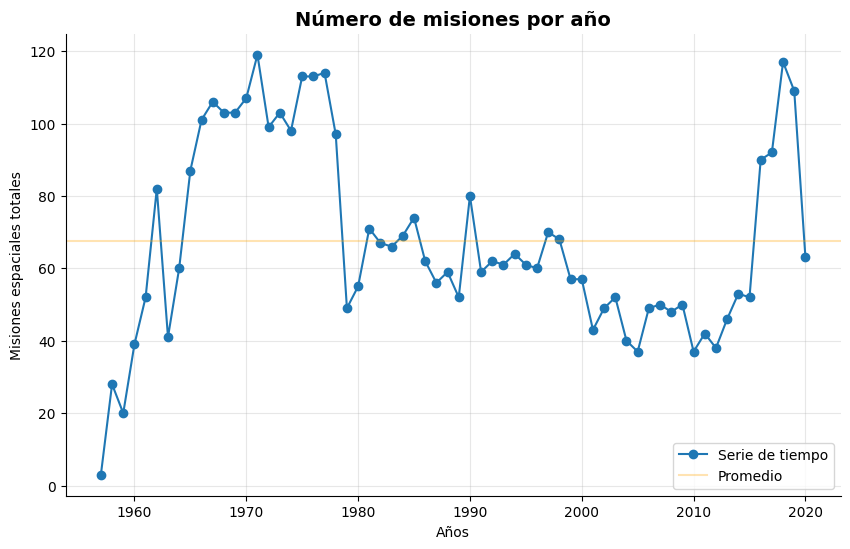

In [12]:
plt.figure(figsize=(10,6))
plt.title("Número de misiones por año", fontsize=14, fontweight='bold')
plt.plot(misiones_por_año, marker="o", label="Serie de tiempo")
plt.ylabel("Misiones espaciales totales")
plt.xlabel("Años")
plt.axhline(y=misiones_por_año.mean(), color="orange", alpha=0.3, label="Promedio")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Misiones por Año.jpg", bbox_inches="tight", dpi=300)
plt.show()

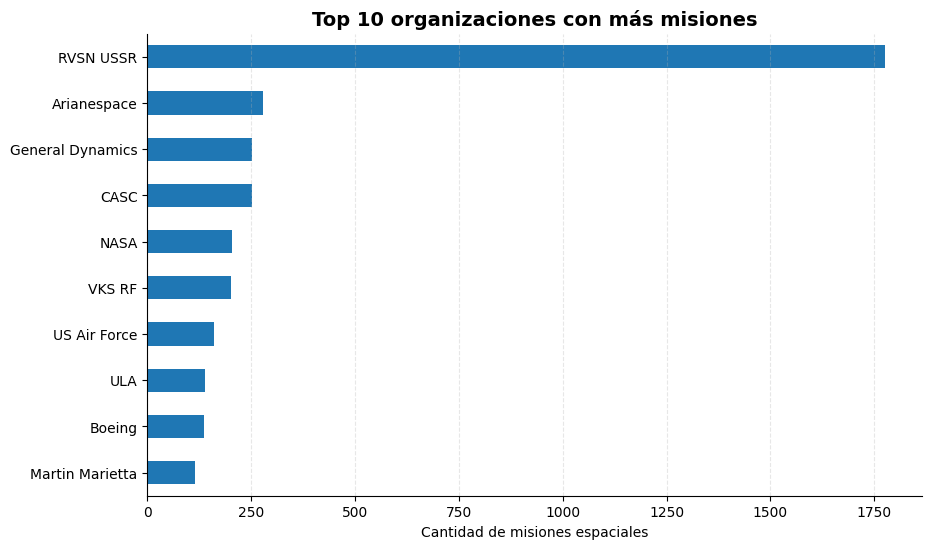

In [13]:
# Ahora haremos la cantidad de viajes por año filtrando por compañías.
# Queremos saber todas las organizaciones que viajaraon al espacio.
organizaciones = df.groupby(df['Organisation']).size()
top10_organizaciones = organizaciones.sort_values().tail(10)

# Mostraremos un gráfico de las compañías que más veces hicieron misiones espaciales.
plt.figure(figsize=(10,6))
plt.title("Top 10 organizaciones con más misiones", fontsize=14, fontweight='bold')
top10_organizaciones.plot(kind='barh')
plt.ylabel("")
plt.xlabel("Cantidad de misiones espaciales")
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Top 10 organizaciones.jpg", bbox_inches="tight", dpi=300)
plt.show()

In [14]:
top10_organizaciones

Organisation
Martin Marietta      114
Boeing               136
ULA                  140
US Air Force         161
VKS RF               201
NASA                 203
CASC                 251
General Dynamics     251
Arianespace          279
RVSN USSR           1777
dtype: int64

In [15]:
# Ahora vamos a mostrar la cantidad de lanzamientos por país.

df["pais"] = df["Location"].str.split(',').str[-1].str.strip()

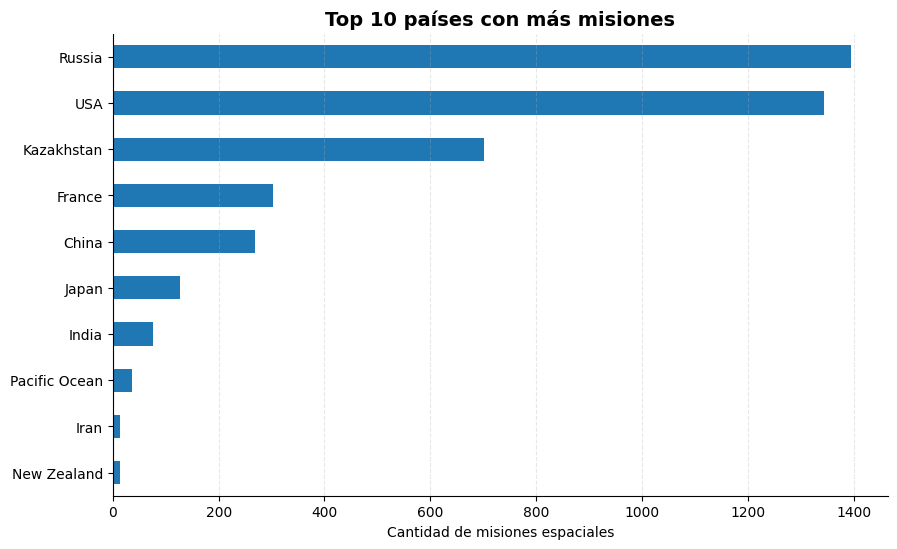

In [16]:
paises = df.groupby(df["pais"]).size()
top10_paises = paises.sort_values().tail(10)

top10_paises
top10_paises.index # Esto nos dice qué países están en esta lista.

plt.figure(figsize=(10,6))
plt.title("Top 10 países con más misiones", fontsize=14, fontweight="bold")
top10_paises.plot(kind="barh")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.ylabel("")
plt.xlabel("Cantidad de misiones espaciales")

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Top 10 países.png", bbox_inches="tight", dpi=300)
plt.show()

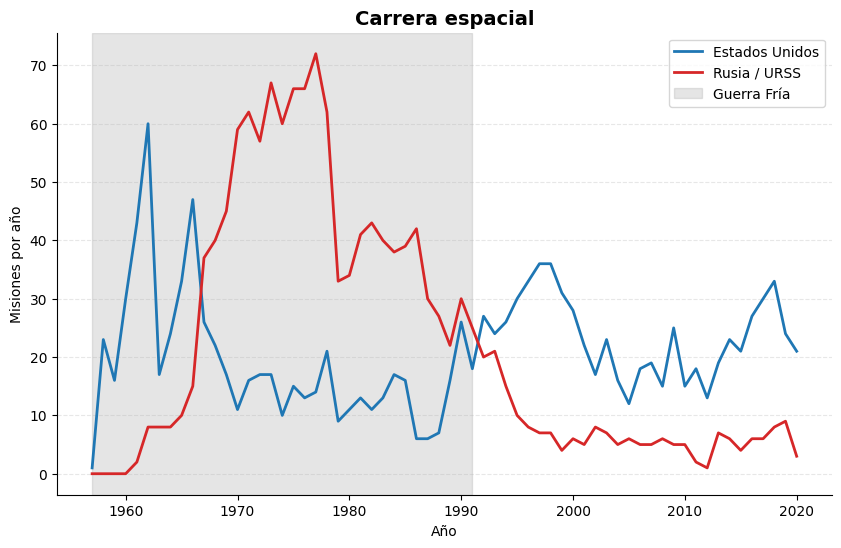

In [17]:
# Ahora vamos a mostrar cómo fue la carrera espacial entre Estados Unidos y Rusia.

paises_interes = ['USA', 'Russia']
df_volumen = df[df['pais'].isin(paises_interes)]
misiones_conteo = df_volumen.groupby([df_volumen['Date'].dt.year, 'pais']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
plt.title("Carrera espacial", fontsize=14, fontweight="bold")
plt.ylabel("Misiones por año")
plt.xlabel("Año")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.plot(misiones_conteo.index, misiones_conteo['USA'], label='Estados Unidos', color='#1f77b4', linewidth=2)
plt.plot(misiones_conteo.index, misiones_conteo['Russia'], label='Rusia / URSS', color='#d62728', linewidth=2)
#plt.axhline(y=misiones_conteo["USA"].mean(), color="#1f77b4", alpha=0.3, label="Promedio USA")
#plt.axhline(y=misiones_conteo["Russia"].mean(), color="#d62728", alpha=0.3, label="Promedio Russia")
plt.axvspan(1957, 1991, color='gray', alpha=0.2, label='Guerra Fría')
plt.legend()

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Carrera espacial.png", bbox_inches="tight", dpi=300)
plt.show()

In [18]:
df["Date"].dt.year.min()
# La guerra fría es de 1947 - 1991. Pero como los datos empiezan en 1947, graficamos desde ahí.

1957

In [19]:
misiones_conteo

pais,Russia,USA
Date,,
1957,0,1
1958,0,23
1959,0,16
1960,0,30
1961,2,43
...,...,...
2016,6,27
2017,6,30
2018,8,33


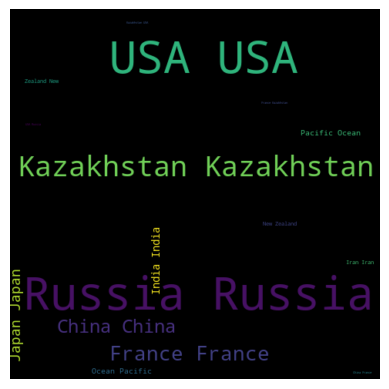

In [20]:
# Create the wordcloud object
# Esto no lo voy a agrgar al final porque no quedó bien.
texto_nube = " ".join([(pais + " ") * cantidad for pais, cantidad in top10_paises.items()])
wordcloud = WordCloud(width=480, height=480, margin=0).generate(texto_nube)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

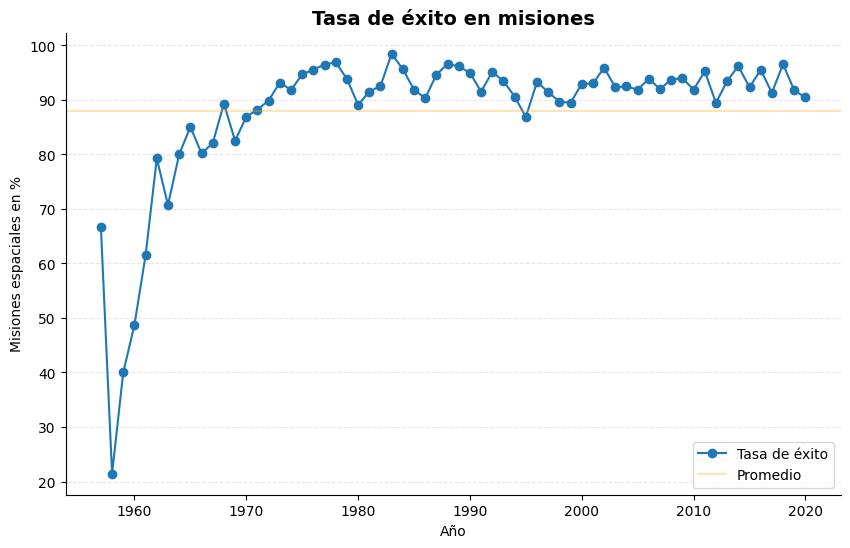

In [21]:
# Ahora graficaremos la cantidad de veces que las misiones fracasan. (O que tienen éxito.)
# 1. Creamos una tabla cruzada (Crosstab) entre el año y el estado de la misión
tabla_exito = pd.crosstab(df["Date"].dt.year, df["Mission_Status"])

# 2. Calculamos el porcentaje
# Dividimos cada fila por su suma total y multiplicamos por 100
porcentaje_exito = tabla_exito.div(tabla_exito.sum(axis=1), axis=0) * 100

# 3. Nos quedamos solo con la columna de 'Success'
solo_success = porcentaje_exito["Success"]

plt.figure(figsize=(10,6))
plt.title("Tasa de éxito en misiones", fontsize=14, fontweight='bold')
plt.plot(solo_success, marker="o", label="Tasa de éxito")
plt.ylabel("Misiones espaciales en %")
plt.xlabel("Año")
plt.axhline(y=solo_success.mean(), color="orange", alpha=0.3, label="Promedio")
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Tasa de éxito.png", bbox_inches="tight", dpi=300)
plt.show()

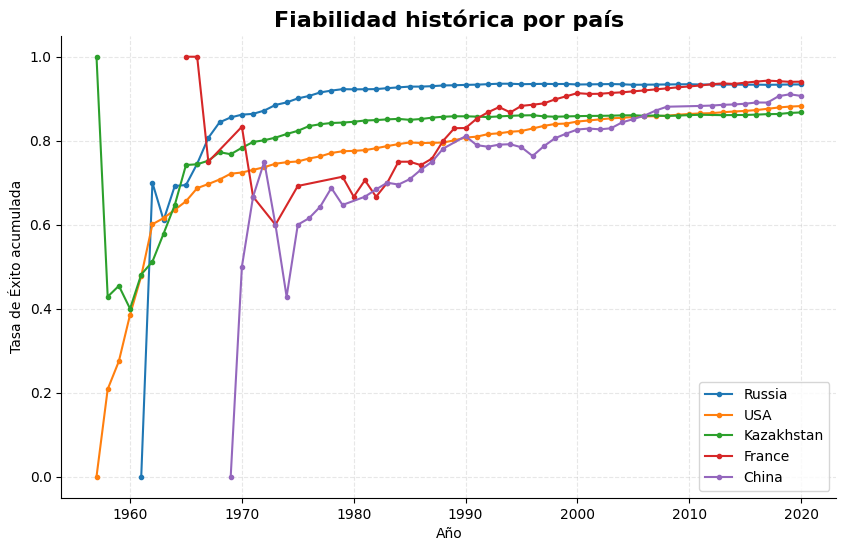

In [22]:
# Ahora queremos ver la fiabilidad histórica de los países.
df["año"] = df["Date"].dt.year
# 1. Identificar los 5 países con más misiones totales
top_5_paises = df['pais'].value_counts().nlargest(5).index

# 2. Filtrar el DataFrame original para quedarnos solo con esos países
# El .copy() es importante porque sino estamos creando una referencia o vista, por lo que al modificar df_top podríamos romper el df original.
# Con .copy() logramos que no se afecte el df original, todo se cambia solamente en df_top.
df_top = df[df['pais'].isin(top_5_paises)].copy()

# 3. Crear una columna binaria de éxito (1 si es Success, 0 si no) (Pandas trabaja más rápido).
df_top['is_success'] = (df_top['Mission_Status'] == 'Success').astype(int)

# 4. Agrupar por país y año para contar misiones y éxitos por año
# Usamos 'count' para el total de misiones y 'sum' para el total de éxitos
stats_por_año = df_top.groupby(['pais', 'año'])['is_success'].agg(['count', 'sum']).reset_index()

# 5. Calcular valores acumulados por país a lo largo de los años
stats_por_año['misiones_acum'] = stats_por_año.groupby('pais')['count'].cumsum()
stats_por_año['exitos_acum'] = stats_por_año.groupby('pais')['sum'].cumsum()

# 6. Calcular la Tasa de Éxito Acumulada
stats_por_año['tasa_acumulada'] = stats_por_año['exitos_acum'] / stats_por_año['misiones_acum']

# 7. Graficar
plt.figure(figsize=(10, 6))
for pais in top_5_paises:
    data_pais = stats_por_año[stats_por_año['pais'] == pais]
    plt.plot(data_pais['año'], data_pais['tasa_acumulada'], marker=".", label=pais)

plt.title('Fiabilidad histórica por país', fontsize=16, fontweight="bold")
plt.xlabel('Año')
plt.ylabel('Tasa de Éxito acumulada')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Fiabilidad histórica países.png", bbox_inches="tight", dpi=300)
plt.show()

In [23]:
stats_por_año

,pais,año,count,sum,misiones_acum,exitos_acum,tasa_acumulada
0,China,1969,1,0,1,0,0.000000
1,China,1970,1,1,2,1,0.500000
2,China,1971,1,1,3,2,0.666667
3,China,1972,1,1,4,3,0.750000
4,China,1973,1,0,5,3,0.600000
...,...,...,...,...,...,...,...
279,USA,2016,27,26,1236,1079,0.872977
280,USA,2017,30,30,1266,1109,0.875987
281,USA,2018,33,33,1299,1142,0.879138
282,USA,2019,24,24,1323,1166,0.881330


In [24]:
df.head(10)

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,pais,año
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,USA,2020
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,2020
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,2020
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,Kazakhstan,2020
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.0,Success,USA,2020
5,5,5,CASC,"LC-9, Taiyuan Satellite Launch Center, China",2020-07-25 03:13:00+00:00,"Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success,China,2020
6,6,6,Roscosmos,"Site 31/6, Baikonur Cosmodrome, Kazakhstan",2020-07-23 14:26:00+00:00,Soyuz 2.1a | Progress MS-15,StatusActive,48.5,Success,Kazakhstan,2020
7,7,7,CASC,"LC-101, Wenchang Satellite Launch Center, China",2020-07-23 04:41:00+00:00,Long March 5 | Tianwen-1,StatusActive,NaN,Success,China,2020
8,8,8,SpaceX,"SLC-40, Cape Canaveral AFS, Florida, USA",2020-07-20 21:30:00+00:00,Falcon 9 Block 5 | ANASIS-II,StatusActive,50.0,Success,USA,2020
9,9,9,JAXA,"LA-Y1, Tanegashima Space Center, Japan",2020-07-19 21:58:00+00:00,H-IIA 202 | Hope Mars Mission,StatusActive,90.0,Success,Japan,2020


In [25]:
# Ahora queremos ver cómo evolucionó la tasa de éxito de las 10 organizaciones con mas vuelos.
# Este código es bastante interesante.

# Elegimos las empresas que queremos comparar (Top 10 por volumen de misiones)
df["año"] = df["Date"].dt.year
top_orgs = df["Organisation"].value_counts().head(10).index
df_top = df[df["Organisation"].isin(top_orgs)]

# Creamos la tabla de tasa de éxito por año y empresa
# Agrupamos y contamos éxitos vs total

stats = df_top.groupby(["año", "Organisation", "Mission_Status"]).size().unstack(fill_value=0)
stats['Total'] = stats.sum(axis=1)
stats['Success_Rate'] = (stats['Success'] / stats['Total']) * 100
stats = stats.reset_index()

In [26]:
df_top["Organisation"].unique()

array(['CASC', 'ULA', 'VKS RF', 'Arianespace', 'NASA', 'Boeing',
       'RVSN USSR', 'General Dynamics', 'Martin Marietta', 'US Air Force'],
      dtype=object)

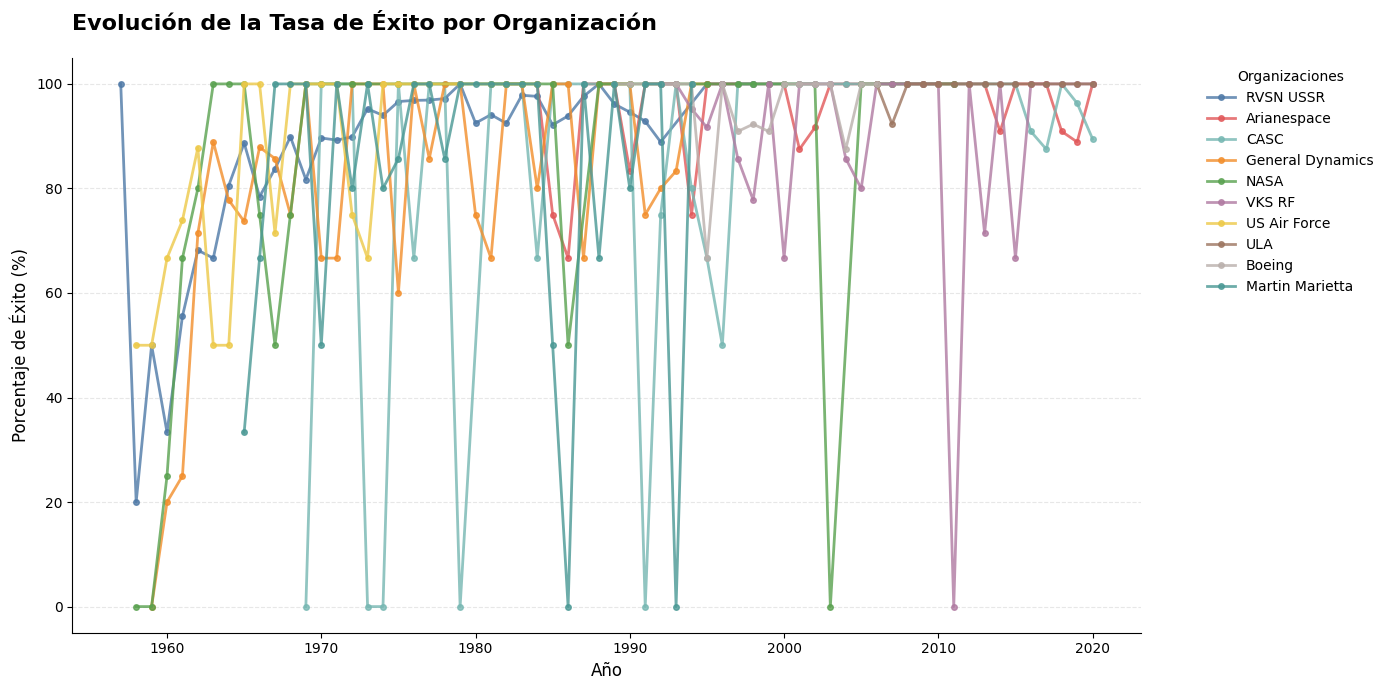

In [27]:
plt.figure(figsize=(14, 7))

# Colores sugeridos para las empresas
#colores = ["red", "blue", "green", "grey", "cyan", "beige", "violet", "yellow", "purple", "brown"]
colores = ['#4E79A7', '#E15759', '#76B7B2', '#F28E2B', '#59A14F', '#B07AA1', '#EDC948', '#9C755F', '#BAB0AC', '#499894']

for org, color in zip(top_orgs, colores):
    data_org = stats[stats["Organisation"] == org]
    # Usamos marker='o' para identificar los puntos de datos reales
    plt.plot(data_org["año"], data_org['Success_Rate'], 
             label=org, color=color, linewidth=2, marker='o', markersize=4, alpha=0.8)

# --- Estética y Limpieza ---
plt.title('Evolución de la Tasa de Éxito por Organización', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje de Éxito (%)', fontsize=12)
plt.ylim(-5, 105) # Un poco de margen abajo para ver caídas al 0%
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Leyenda fuera del gráfico para que no tape las líneas
plt.legend(title="Organizaciones", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# Quitar bordes innecesarios
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
# 1. Ordenamos por empresa y año para que la suma acumulada tenga sentido cronológico
stats = df_top.groupby(["año", "Organisation", "Mission_Status"]).size().unstack(fill_value=0)
stats['Total'] = stats.sum(axis=1)
stats['Success_Rate'] = (stats['Success'] / stats['Total']) * 100
stats = stats.reset_index()
stats = stats.sort_values(['Organisation', 'año'])

# 2. Calculamos la suma acumulada de éxitos y misiones totales por cada empresa
stats['Exitos_Acumulados'] = stats.groupby('Organisation')['Success'].cumsum()
stats['Misiones_Acumuladas'] = stats.groupby('Organisation')['Total'].cumsum()

# 3. La Tasa Acumulada es la división de ambas
stats['Tasa_Acumulada'] = (stats['Exitos_Acumulados'] / stats['Misiones_Acumuladas'])

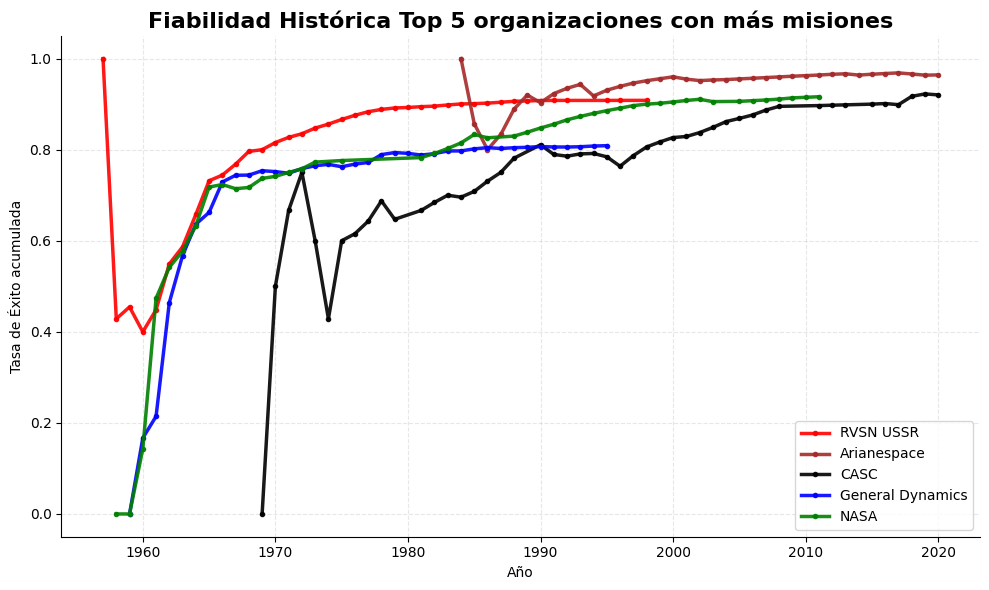

In [29]:
colores = ["red", "brown", "black", "blue", "green"]

plt.figure(figsize=(10, 6))

for org, color in zip(top_orgs, colores):
    data_org = stats[stats["Organisation"] == org]
    
    plt.plot(data_org['año'], data_org['Tasa_Acumulada'], label=org, color=color, linewidth=2.5, marker='.', alpha=0.9)

# Estética profesional
plt.title('Fiabilidad Histórica Top 5 organizaciones con más misiones', fontsize=16, fontweight="bold")
plt.xlabel('Año')
plt.ylabel('Tasa de Éxito acumulada')
#plt.ylim(-5, 105)
plt.grid(linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Limpieza de bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("images/Fiabilidad histórica.png")
plt.show()


In [30]:
df["Mission_Status"].unique()

array(['Success', 'Failure', 'Prelaunch Failure', 'Partial Failure'],
      dtype=object)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Unnamed: 0.1    4324 non-null   int64              
 1   Unnamed: 0      4324 non-null   int64              
 2   Organisation    4324 non-null   object             
 3   Location        4324 non-null   object             
 4   Date            4324 non-null   datetime64[ns, UTC]
 5   Detail          4324 non-null   object             
 6   Rocket_Status   4324 non-null   object             
 7   Price           964 non-null    object             
 8   Mission_Status  4324 non-null   object             
 9   pais            4324 non-null   object             
 10  año             4324 non-null   int32              
dtypes: datetime64[ns, UTC](1), int32(1), int64(2), object(7)
memory usage: 354.8+ KB


In [32]:
df[["Date", "pais"]].sort_values(by="Date").head(20)

,Date,pais
4323,1957-10-04 19:28:00+00:00,Kazakhstan
4322,1957-11-03 02:30:00+00:00,Kazakhstan
4321,1957-12-06 16:44:00+00:00,USA
4320,1958-02-01 03:48:00+00:00,USA
4319,1958-02-05 07:33:00+00:00,USA
4318,1958-03-05 18:27:00+00:00,USA
4317,1958-03-17 12:15:00+00:00,USA
4316,1958-03-26 17:38:00+00:00,USA
4315,1958-04-27 09:01:00+00:00,Kazakhstan
4314,1958-04-28 02:53:00+00:00,USA


In [33]:
df.tail(10)

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,pais,año
4314,4314,4314,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-04-28 02:53:00+00:00,Vanguard | Vanguard TV5,StatusRetired,NaN,Failure,USA,1958
4315,4315,4315,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1958-04-27 09:01:00+00:00,Sputnik 8A91 | Sputnik-3 #1,StatusRetired,NaN,Failure,Kazakhstan,1958
4316,4316,4316,AMBA,"LC-5, Cape Canaveral AFS, Florida, USA",1958-03-26 17:38:00+00:00,Juno I | Explorer 3,StatusRetired,NaN,Success,USA,1958
4317,4317,4317,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-03-17 12:15:00+00:00,Vanguard | Vanguard 1,StatusRetired,NaN,Success,USA,1958
4318,4318,4318,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-03-05 18:27:00+00:00,Juno I | Explorer 2,StatusRetired,NaN,Failure,USA,1958
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,USA,1958
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,StatusRetired,NaN,Success,USA,1958
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,USA,1957
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00+00:00,Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,Kazakhstan,1957
4323,4323,4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-10-04 19:28:00+00:00,Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success,Kazakhstan,1957


In [34]:
# Ahora nos centraremos en el precio.

total_nulos = df["Price"].isnull().sum()
total_nulos

# Del total de 4324 datos, 3360 no tienen precio, por lo que tenemos que descartar esa gran cantidad de datos, y trabajar con lo que lamentablemente tenemos.


3360

## Análisis económico

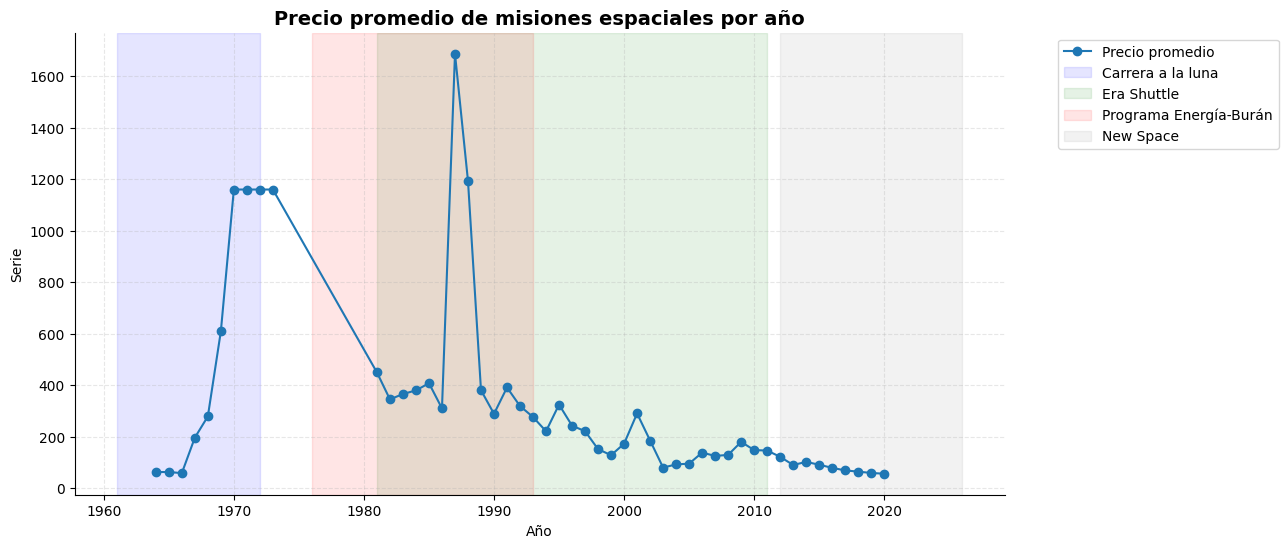

In [35]:
# Ahora analizarmeos el precio.

# Aquí se puede explicar un poco sobre la limpieza de los datos.

df_precio = df.copy()
df_precio = df_precio.dropna(subset=['Price'])
df_precio['Price'] = df_precio['Price'].astype(str).str.replace(',', '').str.strip()
df_precio["Price"] = pd.to_numeric(df_precio["Price"])

precio_promedio = df_precio.groupby("año")["Price"].mean()

plt.figure(figsize=(12, 6))
plt.title("Precio promedio de misiones espaciales por año", fontsize=14, fontweight="bold")
precio_promedio.plot(label="Precio promedio", marker="o")
plt.xlabel("Año")
plt.ylabel("Serie")
plt.grid(linestyle='--', alpha=0.3)

# Fondos

plt.axvspan(1961, 1972, color='blue', alpha=0.1, label='Carrera a la luna')
plt.axvspan(1981, 2011, color='green', alpha=0.1, label='Era Shuttle')
plt.axvspan(1976, 1993, color='red', alpha=0.1, label='Programa Energía-Burán')
plt.axvspan(2012, 2026, color='gray', alpha=0.1, label='New Space')

plt.legend(bbox_to_anchor=(1.05, 1))
# Limpieza de bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Evolución costo promedio por año.png", bbox_inches="tight", dpi=300)
plt.show()

In [36]:
df_precio["Price"].max()

5000.0

## Distribuciones

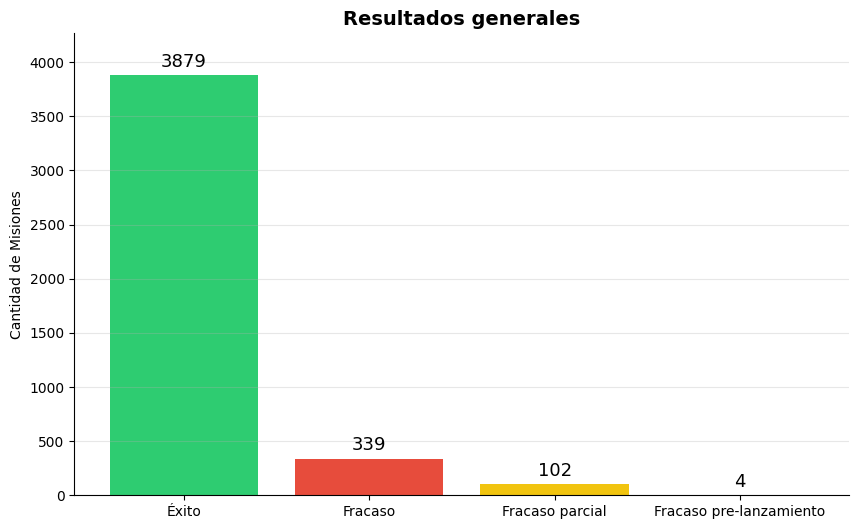

In [37]:
# 1. Preparar los datos (contar frecuencias)
counts = df['Mission_Status'].value_counts()
x_labels = counts.index
y_values = counts.values

# 2. Crear el gráfico
plt.figure(figsize=(10, 6))
barras = plt.bar(x_labels, y_values, color=['#2ecc71', '#e74c3c', '#f1c40f', '#34495e'], tick_label=["Éxito", "Fracaso", "Fracaso parcial", "Fracaso pre-lanzamiento"])

# 3. Agregar las etiquetas (la parte clave)
# Usamos plt.gca() para obtener el eje actual y bar_label
plt.gca().bar_label(barras, padding=3, fontsize=13)

# 4. Estética
plt.title('Resultados generales', fontsize=14, fontweight="bold")
plt.xlabel("", fontsize=12)
plt.ylabel('Cantidad de Misiones')
plt.grid(axis="y", alpha=0.3)

# Ajustar el límite superior para que no se corte la etiqueta
plt.ylim(0, max(y_values) * 1.1)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Resultados generales.png", bbox_inches="tight", dpi=300)
plt.show()

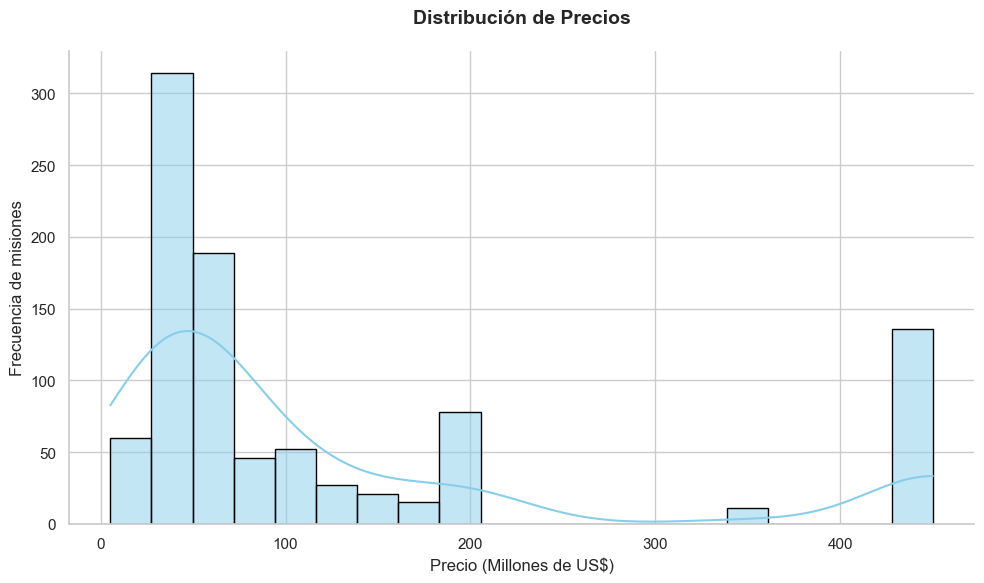

In [38]:
# Configuramos el estilo visual de Seaborn
sns.set_theme(style="whitegrid") 

# Tu filtrado (con el pequeño ajuste de sintaxis)
df_precio2 = df_precio[df_precio["Price"] <= 1000].copy()

# Creamos la figura con un tamaño más cómodo
plt.figure(figsize=(10, 6))

# Usamos sns.histplot para un acabado más moderno
sns.histplot(df_precio2["Price"], 
             bins=20,           # Aumentamos los bins para ver más detalle
             kde=True,          # Añade una línea de densidad (curva suave)
             color="skyblue",   # Color más agradable
             edgecolor="black") # Bordes definidos para las barras

# Personalizamos los textos en español
plt.title("Distribución de Precios", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Precio (Millones de US$)", fontsize=12)
plt.ylabel("Frecuencia de misiones", fontsize=12)

# Guardar y mostrar
plt.tight_layout() # Ajusta los márgenes para que no se corte nada

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Histograma precio.png", bbox_inches="tight", dpi=300) # dpi=300 para alta calidad
plt.show()

## Relación precio/éxito

C:\Users\marco\AppData\Local\Temp\ipykernel_13212\3653140776.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(datos_por_status, patch_artist=True, labels=status_unicos)


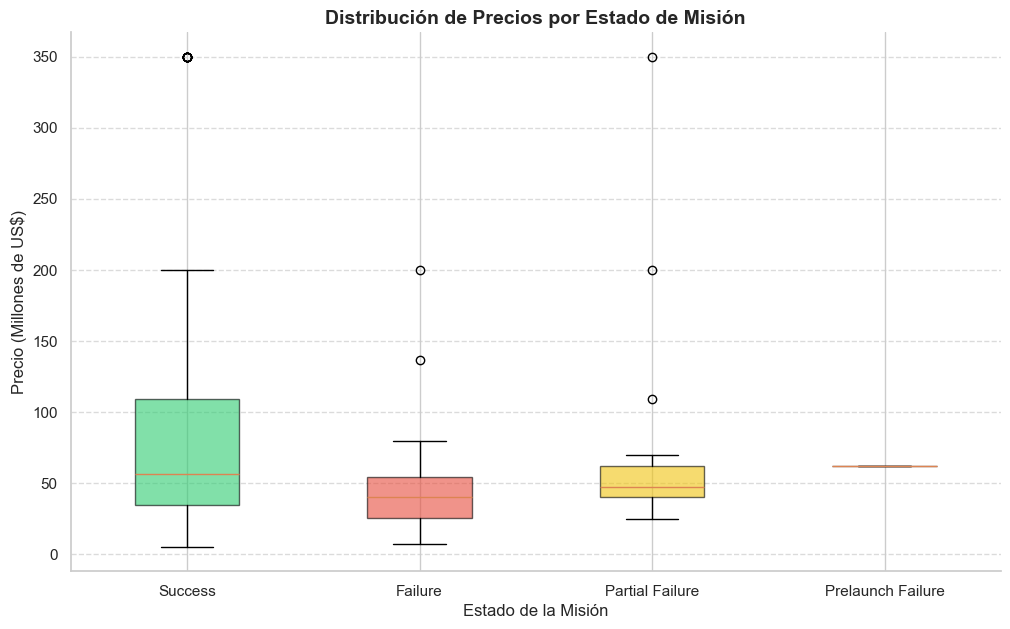

In [39]:
# Eliminamos los valores extremos porque se ve feo.

umbral = df_precio['Price'].quantile(0.95)
df_limpio = df_precio[df_precio['Price'] < umbral]


# 1. Preparar los datos: necesitamos una lista de arrays, uno por cada status
status_unicos = df_limpio['Mission_Status'].unique()
datos_por_status = [df_limpio[df_limpio['Mission_Status'] == s]['Price'] for s in status_unicos]

# 2. Crear el gráfico
plt.figure(figsize=(12, 7))
box = plt.boxplot(datos_por_status, patch_artist=True, labels=status_unicos)

# 3. Personalizar colores
colores = ['#2ecc71', '#e74c3c', '#f1c40f', '#34495e']
for patch, color in zip(box['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 4. Estética
plt.title('Distribución de Precios por Estado de Misión', fontsize=14, fontweight="bold")
plt.ylabel('Precio (Millones de US$)', fontsize=12)
plt.xlabel('Estado de la Misión', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/Boxplot.png", bbox_inches="tight", dpi=300)
plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_13212\2005248537.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(datos_por_status, patch_artist=True, labels=etiquetas_espanol)


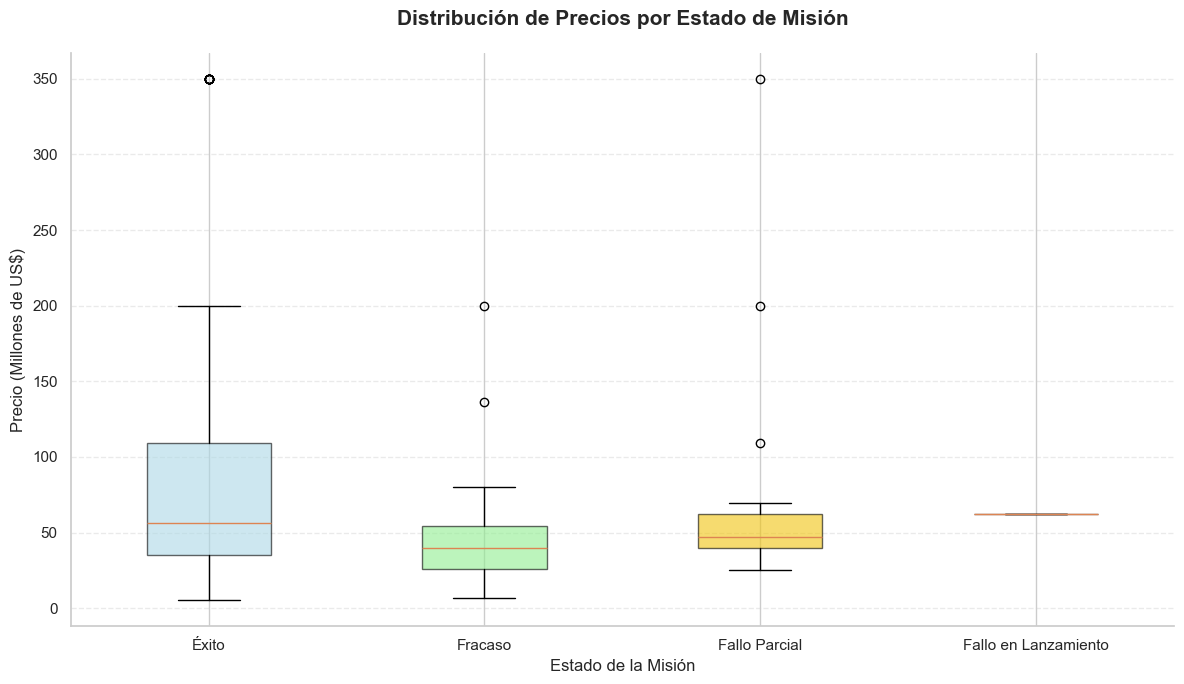

In [40]:
# --- 1. Definir la traducción ---
# Mapeamos los nombres originales a español
traduccion = {
    'Success': 'Éxito',
    'Failure': 'Fracaso',
    'Partial Failure': 'Fallo Parcial',
    'Prelaunch Failure': 'Fallo en Lanzamiento'
}

# Obtenemos los nombres originales y creamos la lista traducida
status_unicos = df_limpio['Mission_Status'].unique()
etiquetas_espanol = [traduccion.get(s, s) for s in status_unicos]

# 2. Preparar los datos
datos_por_status = [df_limpio[df_limpio['Mission_Status'] == s]['Price'] for s in status_unicos]

# 3. Crear el gráfico
plt.figure(figsize=(12, 7))

# Pasamos las etiquetas en español directamente aquí
box = plt.boxplot(datos_por_status, patch_artist=True, labels=etiquetas_espanol)

# 4. Personalizar colores (Aseguramos que coincidan con la cantidad de categorías)
colores = ['lightblue', 'lightgreen', '#f1c40f', '#34495e', 'black'] 
for patch, color in zip(box['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 5. Estética final
plt.title('Distribución de Precios por Estado de Misión', fontsize=15, fontweight="bold", pad=20)
plt.ylabel('Precio (Millones de US$)', fontsize=12)
plt.xlabel('Estado de la Misión', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("images/Boxplot.png", bbox_inches="tight", dpi=300)
plt.show()

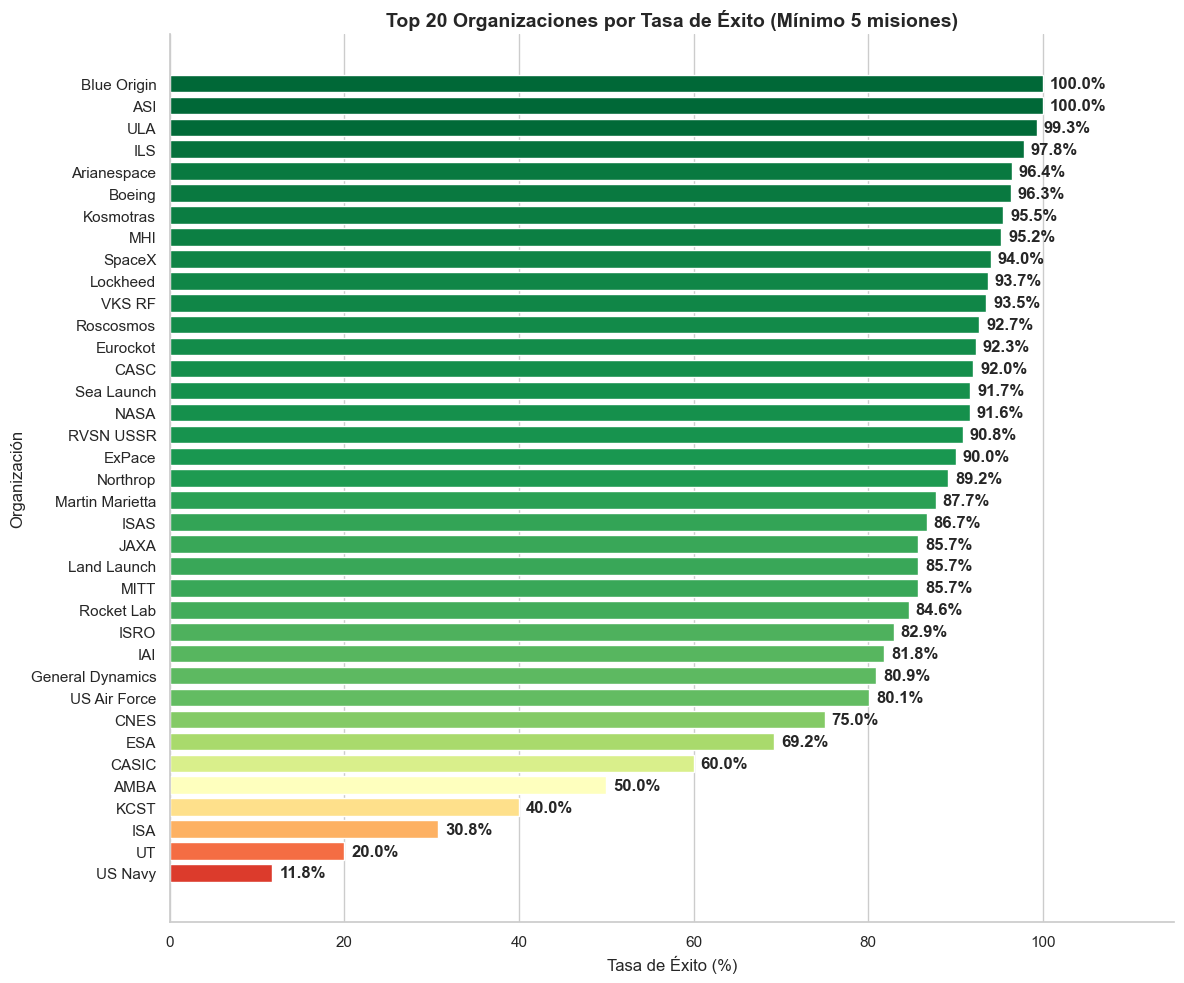

In [41]:
# 1. Calcular el total de misiones y el número de éxitos por organización
# Asumiendo que tu columna de organizaciones se llama 'Organisation'
stats = df.groupby('Organisation')['Mission_Status'].agg(['count', lambda x: (x == 'Success').sum()])
stats.columns = ['Total', 'Exitos']

# 2. Filtrar organizaciones con un mínimo de misiones para un ranking justo
# Ajusta el número (ej. 10) según qué tan grande sea tu dataset
min_misiones = 5
stats_filtrado = stats[stats['Total'] >= min_misiones].copy()

# 3. Calcular la tasa de éxito
stats_filtrado['Tasa_Exito'] = (stats_filtrado['Exitos'] / stats_filtrado['Total']) * 100

# 4. Ordenar y tomar las 20 mejores
top_20_orgs = stats_filtrado.sort_values(by='Tasa_Exito', ascending=False).head(50)

# 5. Graficar
plt.figure(figsize=(12, 10))
# Usamos un color fijo o una lista si prefieres
norm = plt.Normalize(vmin=0, vmax=100)
colores = cm.RdYlGn(norm(top_20_orgs['Tasa_Exito']))
barras = plt.barh(top_20_orgs.index, top_20_orgs['Tasa_Exito'], color=colores)

# 6. Etiquetas y formato
plt.gca().invert_yaxis()  # Para que la mejor organización esté arriba de todo
plt.gca().bar_label(barras, fmt='%.1f%%', padding=5, fontweight='bold')

plt.title(f'Top 20 Organizaciones por Tasa de Éxito (Mínimo {min_misiones} misiones)', fontsize=14, fontweight="bold")
plt.xlabel('Tasa de Éxito (%)', fontsize=12)
plt.ylabel('Organización', fontsize=12)
plt.xlim(0, 115) # Espacio para que quepan las etiquetas de %
plt.grid(axis='y', linestyle='--', alpha=0)

# Limpieza de bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("images/Top20.png")
plt.show()

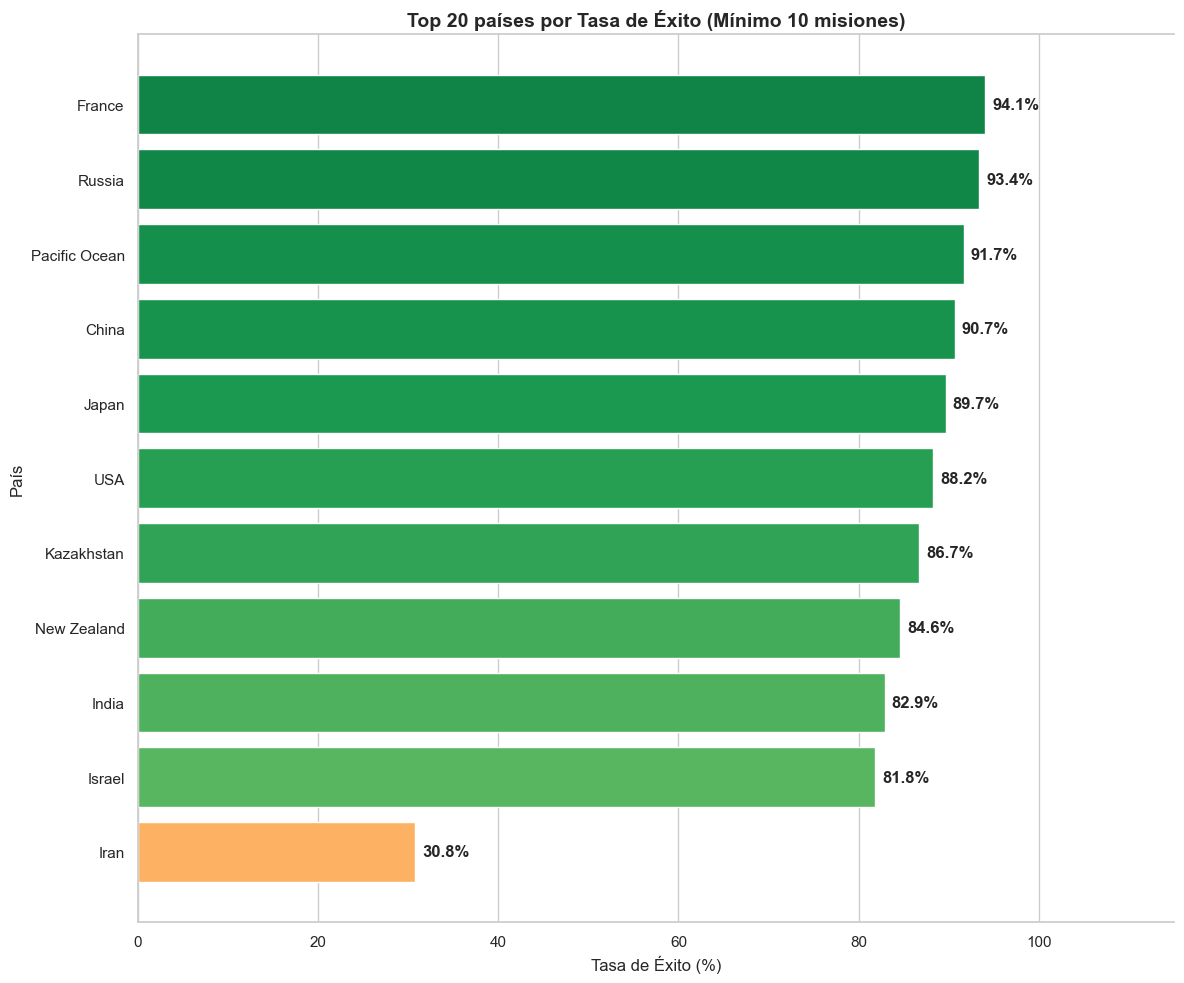

In [42]:
# 1. Calcular el total de misiones y el número de éxitos por organización
# Asumiendo que tu columna de organizaciones se llama 'Organisation'
stats = df.groupby('pais')['Mission_Status'].agg(['count', lambda x: (x == 'Success').sum()])
stats.columns = ['Total', 'Exitos']

# 2. Filtrar organizaciones con un mínimo de misiones para un ranking justo
# Ajusta el número (ej. 10) según qué tan grande sea tu dataset
min_misiones = 10
stats_filtrado = stats[stats['Total'] >= min_misiones].copy()

# 3. Calcular la tasa de éxito
stats_filtrado['Tasa_Exito'] = (stats_filtrado['Exitos'] / stats_filtrado['Total']) * 100

# 4. Ordenar y tomar las 20 mejores
top_20_orgs = stats_filtrado.sort_values(by='Tasa_Exito', ascending=False).head(50)

# 5. Graficar
plt.figure(figsize=(12, 10))
# Usamos un color fijo o una lista si prefieres
norm = plt.Normalize(vmin=0, vmax=100)
colores = cm.RdYlGn(norm(top_20_orgs['Tasa_Exito']))
barras = plt.barh(top_20_orgs.index, top_20_orgs['Tasa_Exito'], color=colores)

# 6. Etiquetas y formato
plt.gca().invert_yaxis()  # Para que la mejor organización esté arriba de todo
plt.gca().bar_label(barras, fmt='%.1f%%', padding=5, fontweight='bold')

plt.title(f'Top 20 países por Tasa de Éxito (Mínimo {min_misiones} misiones)', fontsize=14, fontweight="bold")
plt.xlabel('Tasa de Éxito (%)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.xlim(0, 115) # Espacio para que quepan las etiquetas de %
plt.grid(axis='y', linestyle='--', alpha=0)

# Limpieza de bordes
ax = plt.gca()
# ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("images/Top20pais.png", bbox_inches="tight", dpi=300)
plt.show()

In [43]:
df["pais"].unique()

array(['USA', 'China', 'Kazakhstan', 'Japan', 'Israel', 'New Zealand',
       'Russia', 'Shahrud Missile Test Site', 'France', 'Iran', 'India',
       'New Mexico', 'Yellow Sea', 'North Korea',
       'Pacific Missile Range Facility', 'Pacific Ocean', 'South Korea',
       'Barents Sea', 'Brazil', 'Gran Canaria', 'Kenya', 'Australia'],
      dtype=object)